# 02 · XGBoost - second-order boosting

XGBoost's signature ideas:

1. **Newton (2nd-order) boosting.** Where our scratch model used only the
   residual (1st-order gradient), XGBoost also uses the **Hessian** (2nd
   derivative) to decide splits and leaf values - a more accurate step.
2. **Regularization built into the objective:** an L2 penalty on leaf weights
   (`reg_lambda`) and a complexity penalty per leaf (`gamma`).
3. **`max_depth`-driven, level-wise** tree growth.

The regularized objective for one tree with leaf weights $w_j$:
$$ \mathcal{L} = \sum_i \big[g_i w + \tfrac12 h_i w^2\big]
   + \gamma T + \tfrac12 \lambda \sum_j w_j^2 $$

In [1]:
import os, sys, warnings, time
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option("display.precision", 3)
from utils import data as D
from utils import plotting as P
from sklearn.metrics import root_mean_squared_error, r2_score

df = pd.read_parquet("../data/regression.parquet")
y = df.pop("target")
X = df                                        # keeps 'category' as a categorical dtype
Xtr, Xte, ytr, yte = D.train_test_split_df(X, y, test_size=0.25, seed=0)


In [ ]:
from xgboost import XGBRegressor

# XGBoost 3.x supports native categoricals via enable_categorical=True.
model = XGBRegressor(
    n_estimators=400, learning_rate=0.05, max_depth=4,
    reg_lambda=1.0, subsample=0.8, colsample_bytree=0.8,
    enable_categorical=True, eval_metric="rmse", early_stopping_rounds=30,
    random_state=0,
)
model.fit(Xtr, ytr, eval_set=[(Xtr, ytr), (Xte, yte)], verbose=False)
print("best iteration:", model.best_iteration)
print("test RMSE:", round(root_mean_squared_error(yte, model.predict(Xte)), 3),
      "| R2:", round(r2_score(yte, model.predict(Xte)), 3)) # R2 measures how much closer the model's prediction is to reality. 1 being best, lesser it goes the worse it is

best iteration: 399
test RMSE: 1.639 | R2: 0.907


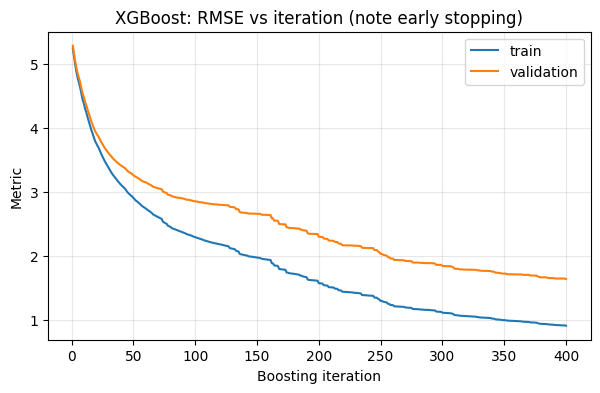

In [3]:
# Training curve straight from XGBoost's recorded eval history.
hist = model.evals_result()
P.plot_training_curve({"train": hist["validation_0"]["rmse"],
                       "validation": hist["validation_1"]["rmse"]},
                      title="XGBoost: RMSE vs iteration (note early stopping)")
plt.show()

## Did it find the planted signal?

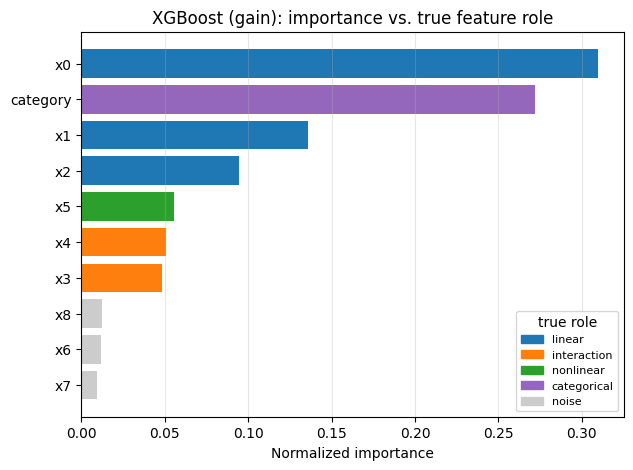

In [5]:
imp = dict(zip(X.columns, model.feature_importances_))
# Rebuild the ground truth (deterministic with the same seed) to grade against.
_, _, gt = D.make_dataset("regression", n_samples=4000, seed=42)
P.plot_importance_vs_truth(imp, gt, model_name="XGBoost (gain)")
plt.show()

## Regularization in action

Increasing `reg_lambda` and reducing `max_depth` simplify the model. Watch the
validation RMSE respond.

reg_lambda   0.0    1.0    10.0
max_depth                      
2           2.824  2.875  2.817
4           2.211  2.255  2.179
6           2.035  1.983  2.040
10          2.912  2.689  2.375


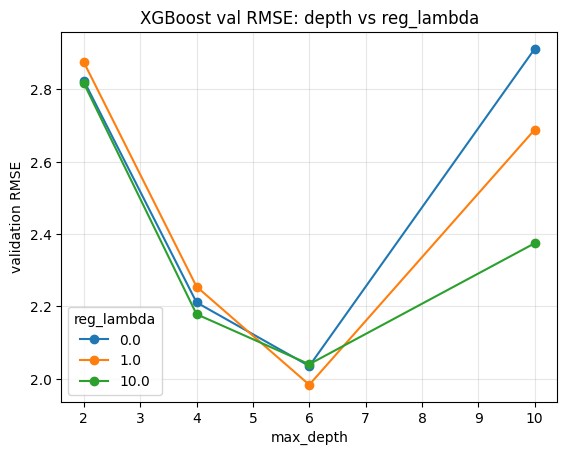

In [6]:
rows = []
for depth in [2, 4, 6, 10]:
    for lam in [0.0, 1.0, 10.0]:
        m = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=depth,
                         reg_lambda=lam, enable_categorical=True,
                         random_state=0)
        m.fit(Xtr, ytr, verbose=False)
        rows.append({"max_depth": depth, "reg_lambda": lam,
                     "val_RMSE": root_mean_squared_error(yte, m.predict(Xte))})
pivot = pd.DataFrame(rows).pivot(index="max_depth", columns="reg_lambda",
                                 values="val_RMSE")
print(pivot.round(3))
pivot.plot(marker="o", title="XGBoost val RMSE: depth vs reg_lambda")
plt.ylabel("validation RMSE"); plt.grid(alpha=0.3); plt.show()

## SHAP - explaining individual predictions

SHAP fairly attributes each prediction to features. We compute mean-|SHAP| as an
importance and check the planted **interaction** with a dependence plot.

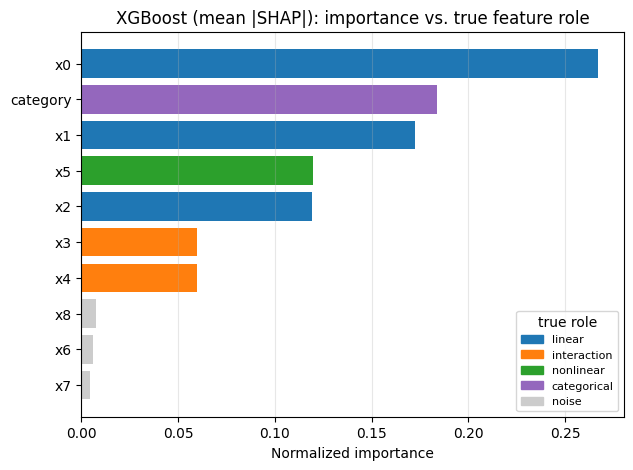

In [7]:
import shap
Xte_enc = D.encode_categorical(Xte)              # SHAP TreeExplainer wants numeric
expl = shap.TreeExplainer(model)
sv = expl.shap_values(Xte_enc)
mean_abs = dict(zip(X.columns, np.abs(sv).mean(0)))
P.plot_importance_vs_truth(mean_abs, gt, model_name="XGBoost (mean |SHAP|)")
plt.show()

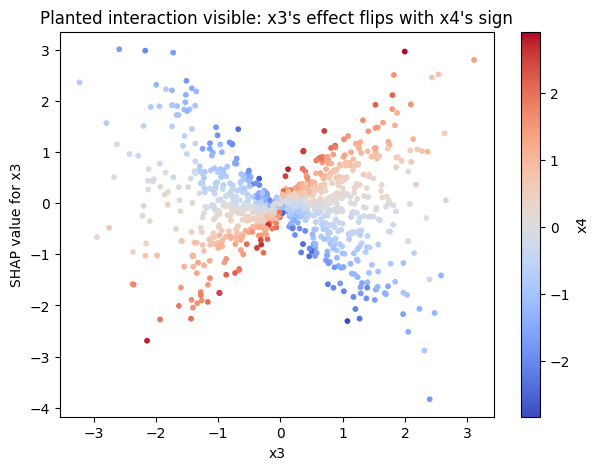

In [8]:
# Interaction check: SHAP value for x3 should depend on x4 (and vice-versa).
j3 = list(X.columns).index("x3")
fig, ax = plt.subplots(figsize=(7,5))
sc = ax.scatter(Xte["x3"], sv[:, j3], c=Xte["x4"], cmap="coolwarm", s=10)
plt.colorbar(sc, label="x4")
ax.set(xlabel="x3", ylabel="SHAP value for x3",
       title="Planted interaction visible: x3's effect flips with x4's sign")
plt.show()

## Takeaways
- Second-order gradients + explicit regularization make XGBoost robust.
- `early_stopping_rounds` picks the tree count for you.
- SHAP recovers the linear effects, the x3·x4 interaction, and ~zero for noise.

Next: **`03_lightgbm`**.